# Import Packages

In [1]:
import abm
import numpy as np
from plotnine import *
import pandas as pd

# Simulate Model
## Load IQ Design Model File

In [2]:
model = 'inputs/Models/2compartment_Ab.iqd'

## Simulations
### Run Default IQ Design Model Parameters and Conditions

In [3]:
Tdefault = abm.simulate(models = model,
                        times = abm.linspace(0,35,351, 'd'),
                        outputs = ['free_drug_c', 'RO_c']).to_pandas(tall_outputs = True)

Total: 1, Running: 0, Succeeded: 1, Failed: 0

In [4]:
display(Tdefault.head())

,id,t,output,value,output_unit
0,0,0.0,free_drug_c,1555.555556,nM
1,0,0.0,RO_c,0.000000,1
2,0,0.1,free_drug_c,1361.306880,nM
3,0,0.1,RO_c,93.156668,1
4,0,0.2,free_drug_c,1211.061272,nM


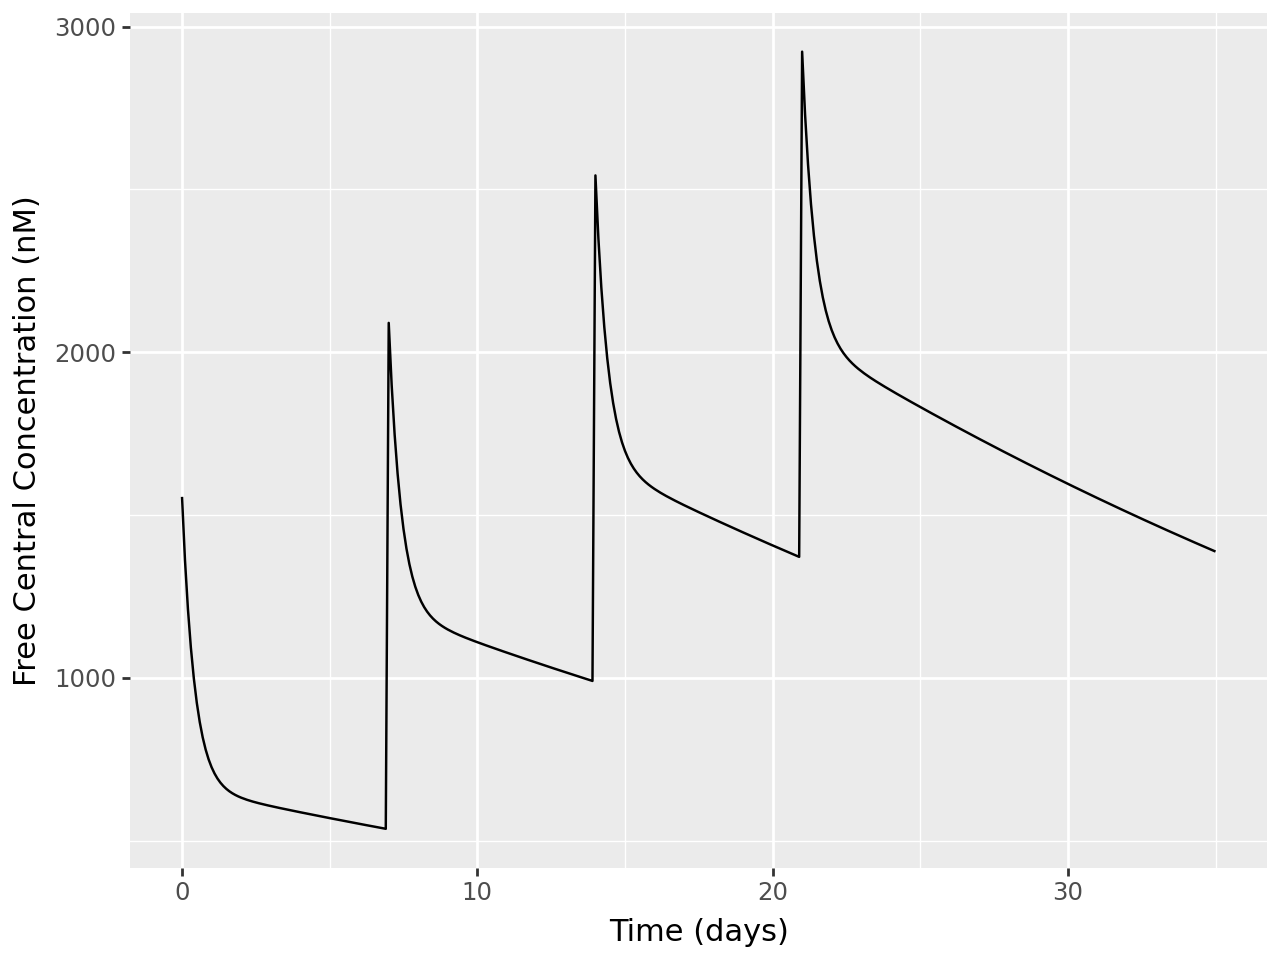

In [5]:
# PK plot - linear axis
fig_PK = (ggplot()
          + geom_line(data = Tdefault.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)')
         )

display(fig_PK)

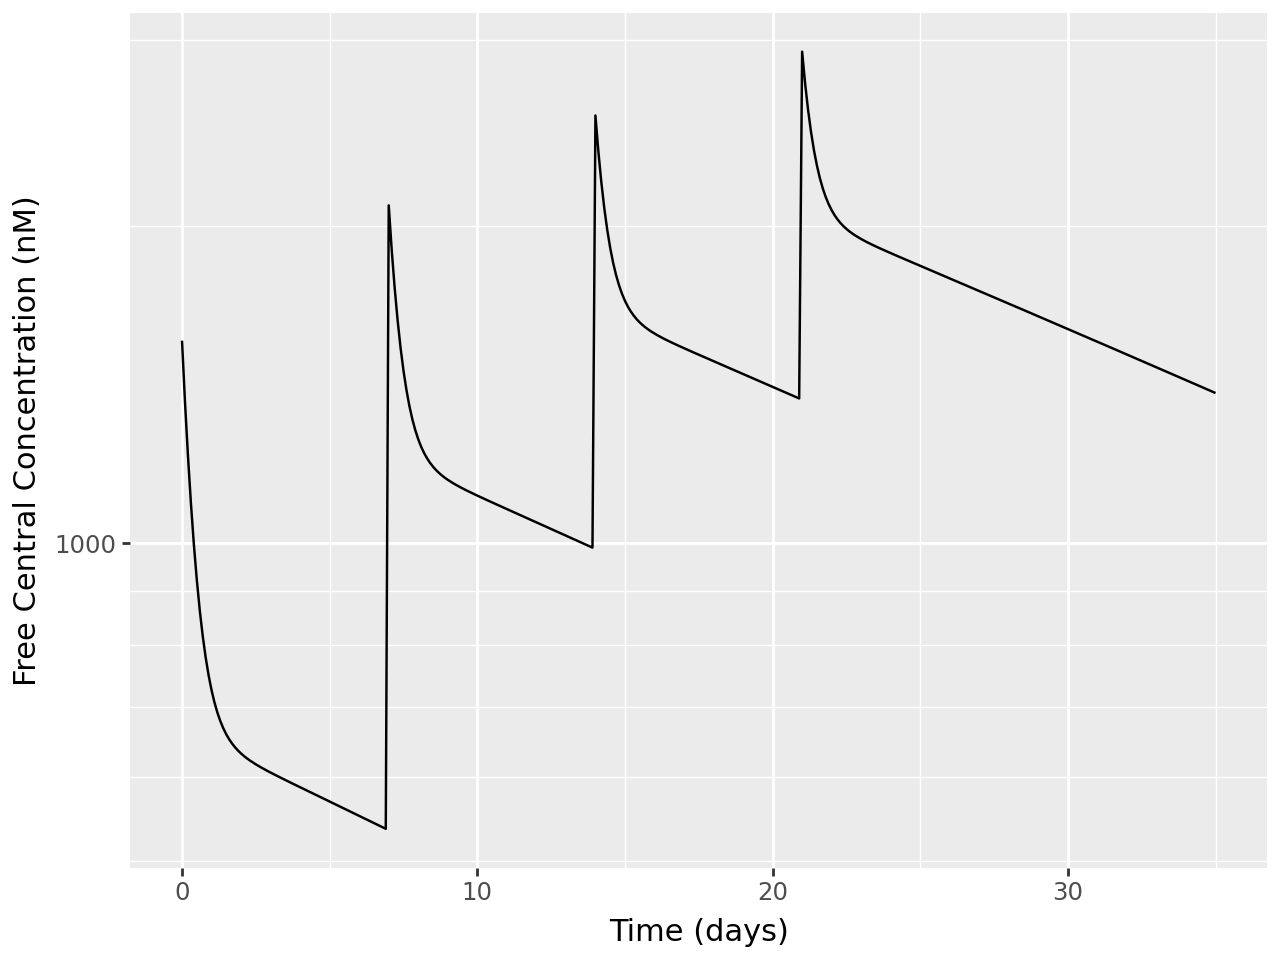

In [6]:
# PK plot - log axis
fig_PK = (ggplot()
          + geom_line(data = Tdefault.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)')
          + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
         )

display(fig_PK)

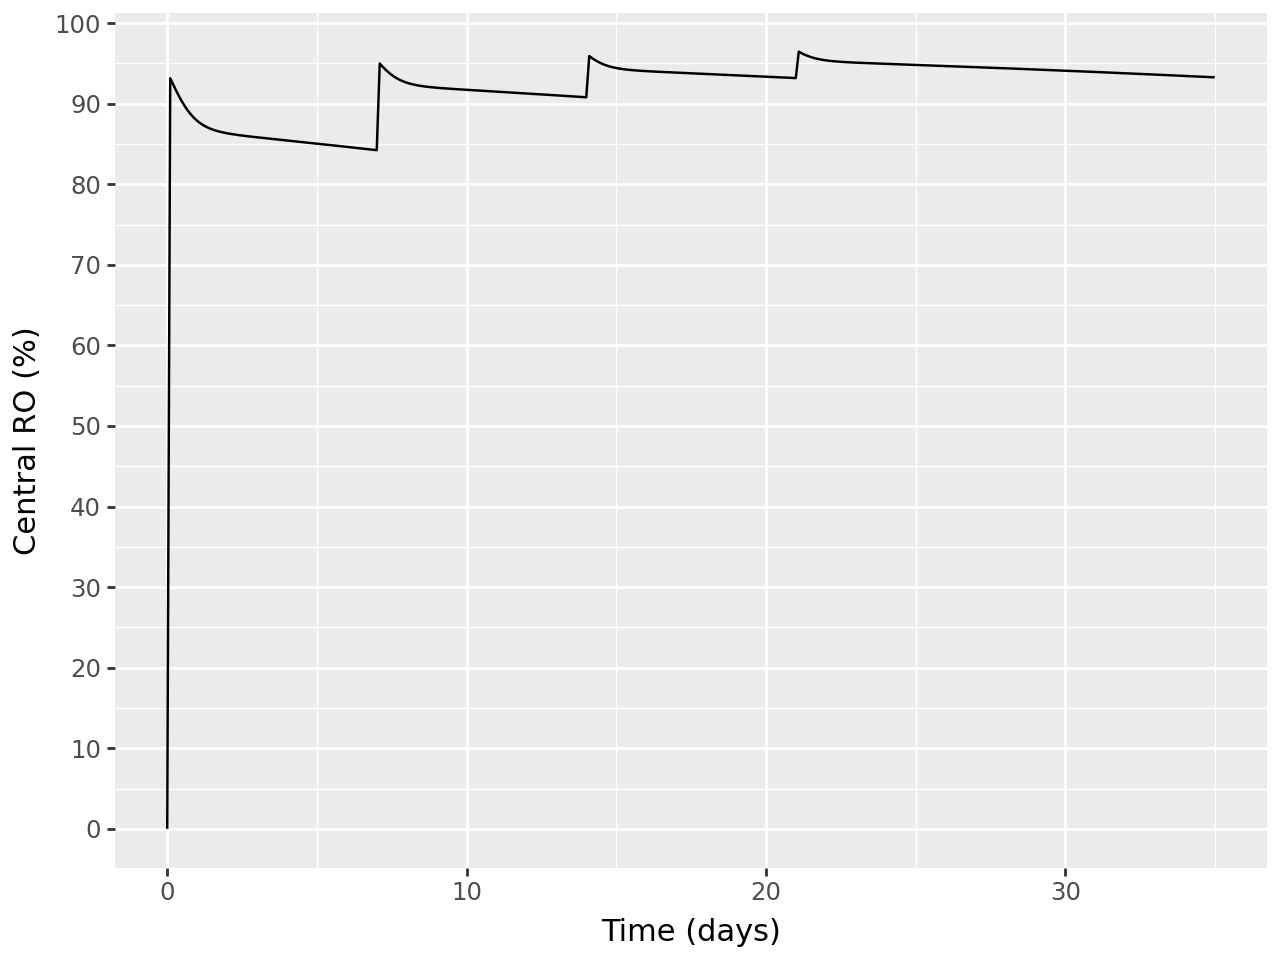

In [7]:
# RO plot - linear axis
fig_PK = (ggplot()
          + geom_line(data = Tdefault.query('output == "RO_c"'), mapping = aes(x = 't', y = 'value'))
          + labs(x = 'Time (days)', y = 'Central RO (%)')
          + scale_y_continuous(breaks = np.linspace(0,100,11))
         )

display(fig_PK)

## Custom Parameters
### Load Custom Parameter Table

In [8]:
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

In [9]:
display(Tpar.head())

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.0,False,NaN,NaN
1,Volume_p,L,13.0,False,NaN,NaN
2,MW,kDa,150.0,False,NaN,NaN
3,BW,kg,70.0,False,NaN,NaN
4,Pdist,1,0.3,False,NaN,NaN


### Run Custom Parameter Table and Default Conditions

In [10]:
TcustomP = abm.simulate(models = model,
                        parameters = Tpar,
                        times = abm.linspace(0,35,351, 'd'),
                        outputs = ['free_drug_c', 'RO_c']).to_pandas(tall_outputs = True)

Total: 1, Running: 0, Succeeded: 1, Failed: 0

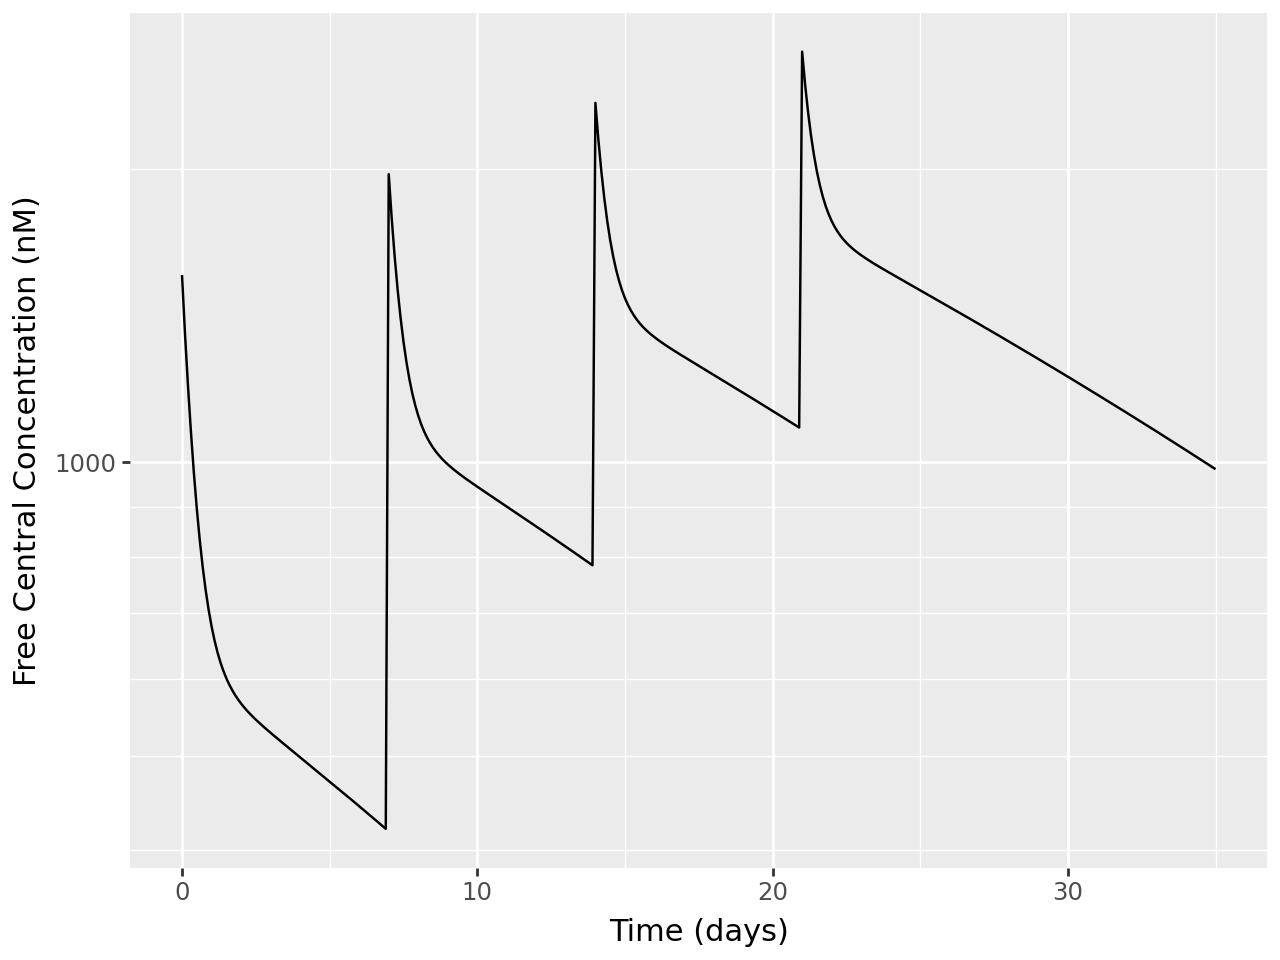

In [11]:
# PK plot - log axis
fig_PK = (ggplot()
          + geom_line(data = TcustomP.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)')
          + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
         )

display(fig_PK)

In [12]:
Tcompare = pd.concat([Tdefault.assign(setup = 'default'), TcustomP.assign(setup = 'custom Par')])

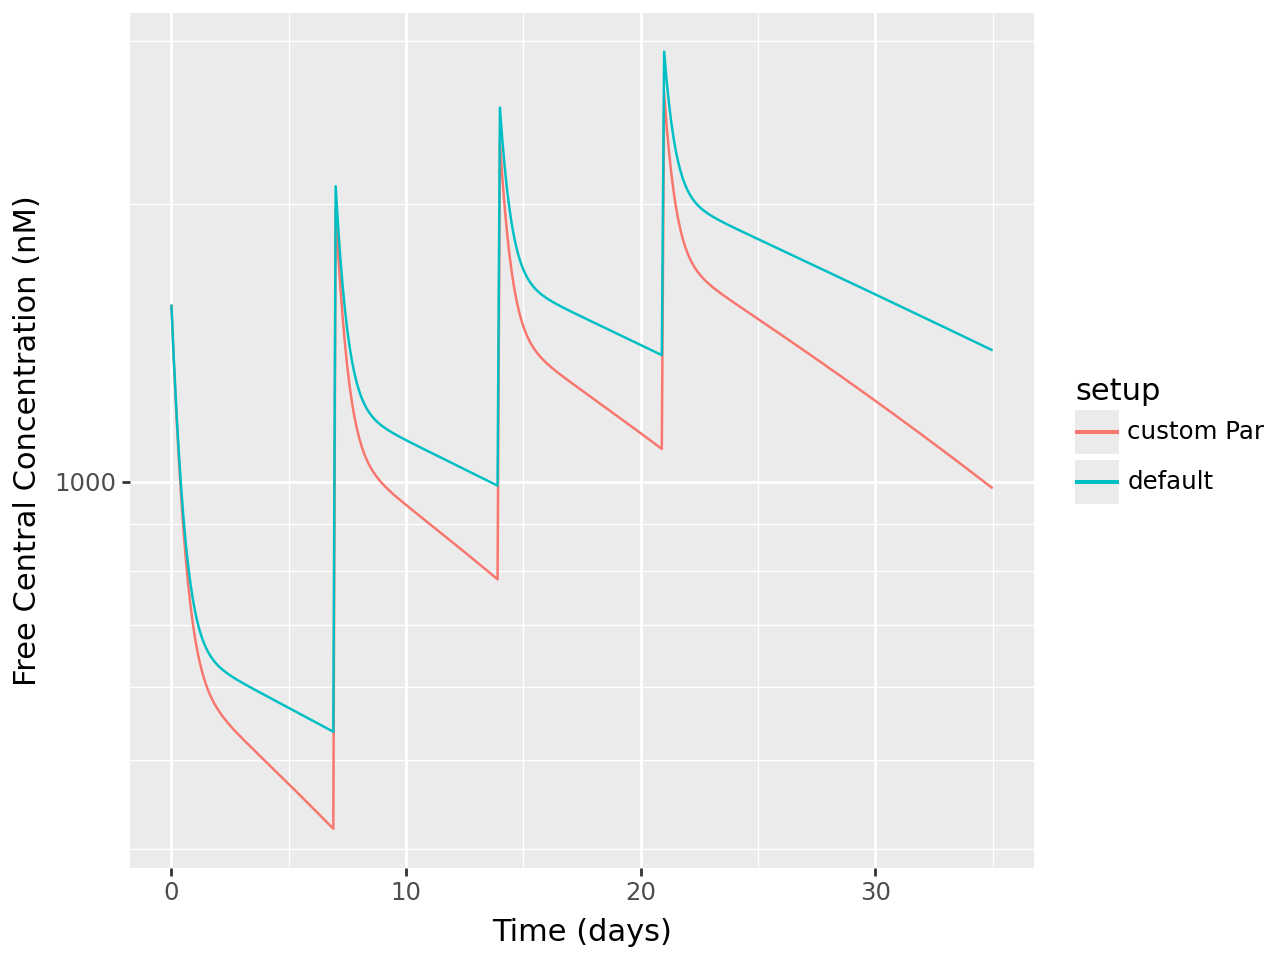

In [13]:
# PK plot - log axis
fig_PK = (ggplot()
          + geom_line(data = Tcompare.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value', color = 'setup'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)')
          + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
         )

display(fig_PK)

## Custom Dosing
### Create Custom Conditions/Dosing Table

In [14]:
doses = [0.1, 0.3, 1, 3, 10, 30]
times = [0, 7, 14, 21, 28]

TdosIV = pd.DataFrame({'dose_mpk':doses,
                       'amounts':doses,
                       'times':[times] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg', route = 'Dose_IV')
TdosSC = pd.DataFrame({'dose_mpk':doses,
                       'amounts':doses,
                       'times':[times] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg', route = 'Dose_SC')

Tdos = pd.concat([TdosIV, TdosSC])

Tsim = Tdos[['dose_mpk', 'route']]

Tpar2 = Tpar.copy()
Tpar2 = pd.concat([Tpar, pd.DataFrame({'parameter':['Dose_amt_IV', 'Dose_amt_SC']}).assign(unit = 'mg/kg', value = 0, is_fit = False)])

In [15]:
display(Tdos)

,dose_mpk,amounts,times,time_unit,amount_unit,route
0,0.1,0.1,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
1,0.3,0.3,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
2,1.0,1.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
3,3.0,3.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
4,10.0,10.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
5,30.0,30.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_IV
0,0.1,0.1,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC
1,0.3,0.3,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC
2,1.0,1.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC
3,3.0,3.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC


### Simulate Custom Conditions and Custom Parameters

In [16]:
Tcustom = abm.simulate(models = model,
                       outputs = ['free_drug_c', 'RO_c'],
                       doses = Tdos,
                       simulations = Tsim,
                       parameters = Tpar2,
                       times = abm.linspace(0,35,351, 'd')).to_pandas(tall_outputs = True)

Total: 12, Running: 0, Succeeded: 12, Failed: 0

In [17]:
display(Tcustom.head())

,dose_mpk,route,id,t,output,value,output_unit
0,0.1,Dose_IV,0,0.0,free_drug_c,15.555556,nM
1,0.1,Dose_IV,0,0.0,RO_c,0.000000,1
2,0.1,Dose_IV,0,0.1,free_drug_c,12.532196,nM
3,0.1,Dose_IV,0,0.1,RO_c,12.223765,1
4,0.1,Dose_IV,0,0.2,free_drug_c,11.163680,nM


/home/jovyan/environment/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


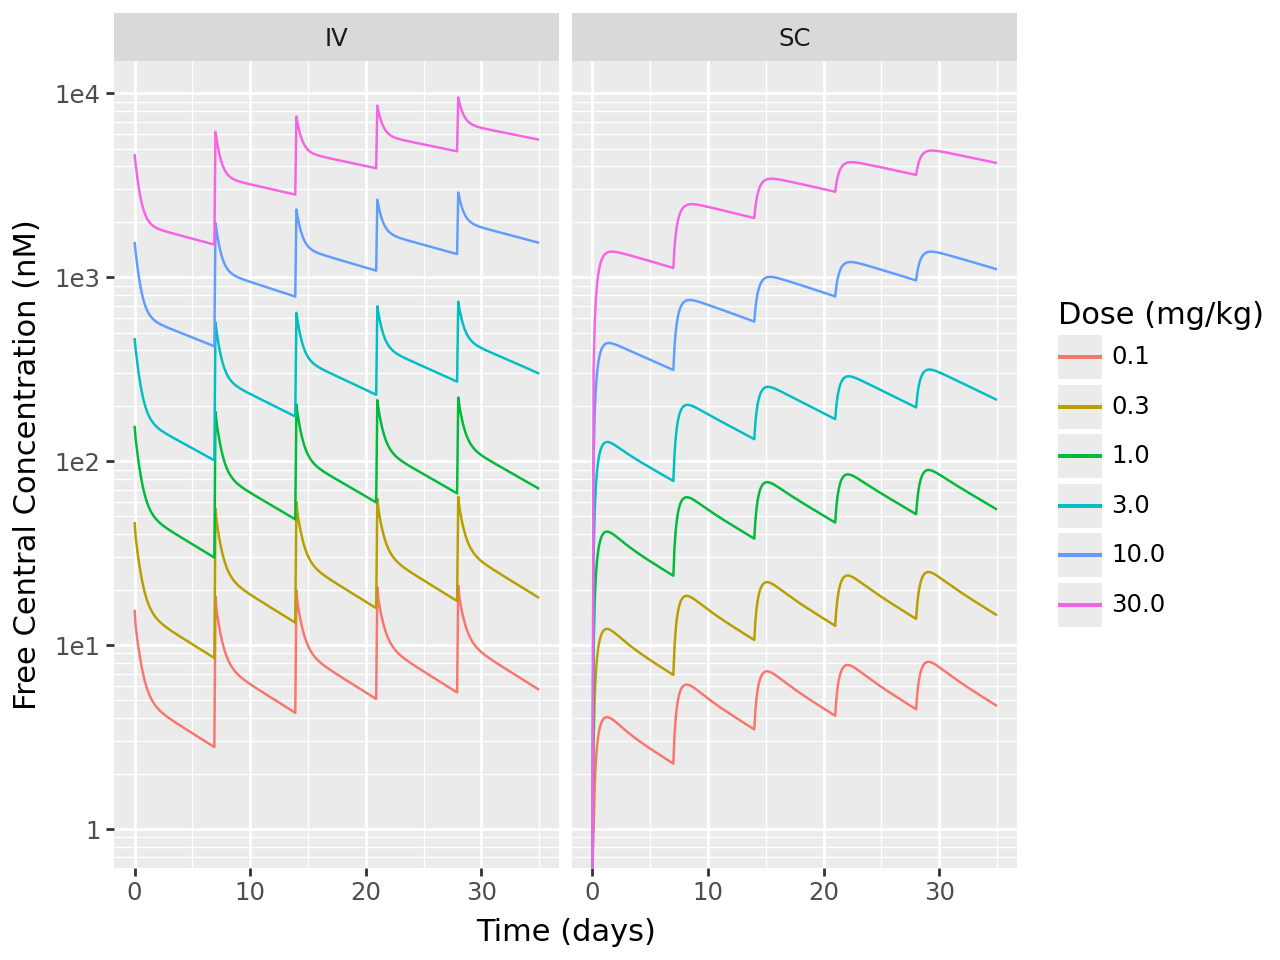

In [18]:
# PK plot - log axis
fig_PK = (ggplot()
          + geom_line(data = Tcustom.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)', color = 'Dose (mg/kg)')
          + facet_wrap('route', labeller = lambda x: x.split('_')[1])
          + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
         )

display(fig_PK)

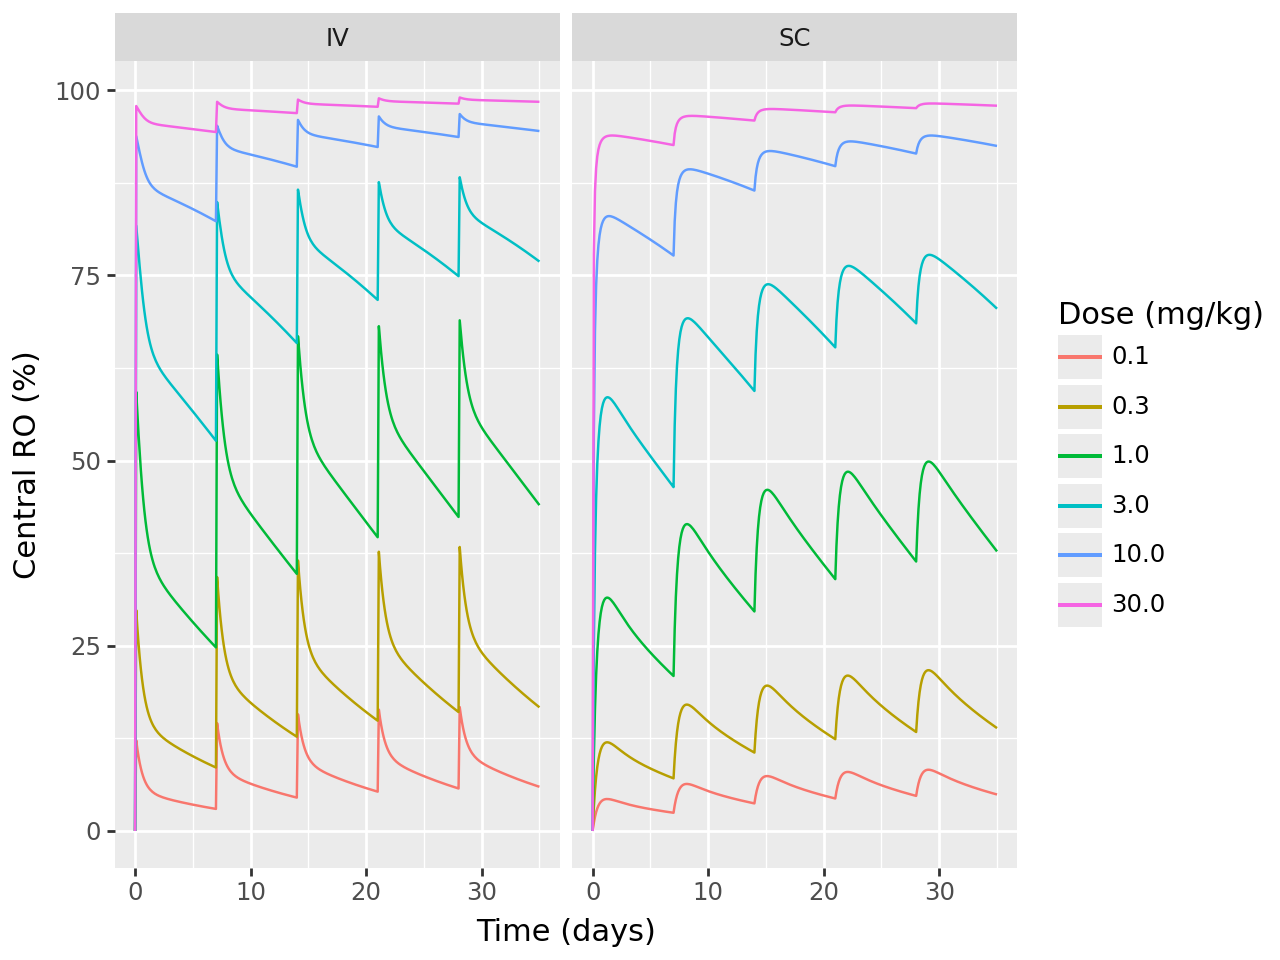

In [19]:
# RO plot - linear axis
fig_RO = (ggplot()
          + geom_line(data = Tcustom.query('output == "RO_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
          + labs(x = 'Time (days)', y = 'Central RO (%)', color = 'Dose (mg/kg)')
          + facet_wrap('route', labeller = lambda x: x.split('_')[1])
         )

display(fig_RO)